# VRT Semantic CRP Report

Report-style notebook for semantic distance-conditioned recall probabilities in the VRT dataset.
Default response mask excludes cued responses (`cue_clips == 0`).

In [1]:
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jaxcmr.analyses.conditional_distcrp import plot_dist_crp
from jaxcmr.helpers import find_project_root, load_data

warnings.filterwarnings("ignore")


def save_figure(figure_dir, figure_str, suffix=None):
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

In [2]:
run_tag = "VRT_SEMANTIC_CRP"
data_path = "data/VRT_clips.h5"
features_path = "data/VRT_clip_embeddings.npy"
figure_dir = "results/figures"
figure_str = ""
ylim = None
use_first_phase_only = True

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)

# Load clip embeddings
features = np.load(os.path.join(project_root, features_path)).astype(np.float32)
print(f"Features shape: {features.shape}")

task = data["task"]
condition = data["condition"]
intervention = data["intervention"]
intentionality = data["intentionality"]

# Response mask: exclude cued transitions
response_mask = data["cue_clips"] == 0


def trial_mask(mask):
    return jnp.asarray(mask).reshape(-1)


first_phase_mask = trial_mask(
    ((task == 1) & (intentionality == 1)) | ((task == 2) & (intentionality == 2))
)
phase_label = "First Phase" if use_first_phase_only else "All Phases"


def phase_mask(mask):
    base = trial_mask(mask)
    return base & first_phase_mask if use_first_phase_only else base


def summarize_masks(labels, masks):
    for label, mask in zip(labels, masks):
        n_trials = int(jnp.sum(mask))
        n_subjects = int(jnp.unique(data["subject"][mask]).size)
        print(f"{label}: trials={n_trials}, subjects={n_subjects}")


def plot_contrast(masks, labels, contrast_name, axis=None, suffix=None):
    plot_dist_crp(
        datasets=[data] * len(masks),
        trial_masks=masks,
        should_tabulate=[response_mask] * len(masks),
        features=features,
        labels=labels,
        contrast_name=contrast_name,
        axis=axis,
    )
    if ylim is not None:
        for ax in plt.gcf().axes:
            ax.set_ylim(ylim)
    if axis is None:
        save_figure(figure_dir, figure_str, suffix=suffix or contrast_name)

Features shape: (22, 768)


## Q1. Is Semantic CRP Different Between Involuntary And Voluntary Tasks?

Involuntary: trials=240, subjects=240
Voluntary: trials=240, subjects=240


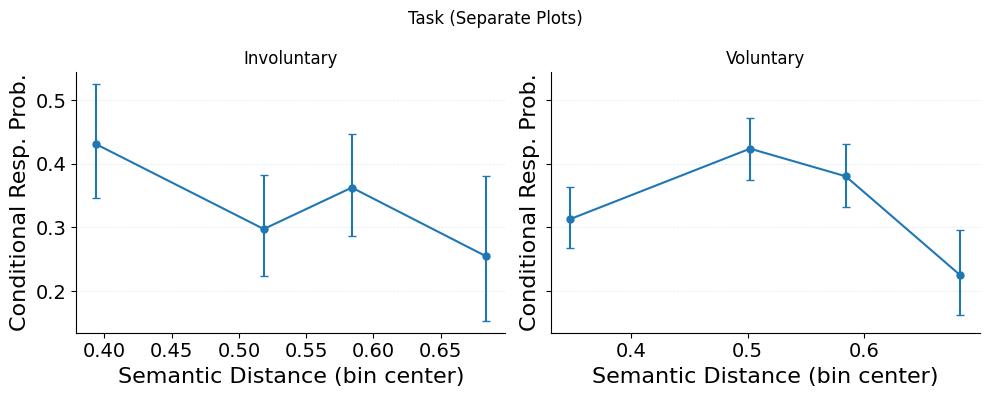

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

labels = ["Involuntary", "Voluntary"]
masks = [trial_mask(task == 1), trial_mask(task == 2)]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Involuntary")
plot_contrast([masks[1]], [labels[1]], contrast_name=None, axis=axes[1])
axes[1].set_title("Voluntary")

fig.suptitle("Task (Separate Plots)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="semantic_task_separate")

## Q2. Task × Condition (Emotional Vs Neutral)

Emotional: trials=120, subjects=120
Neutral: trials=120, subjects=120


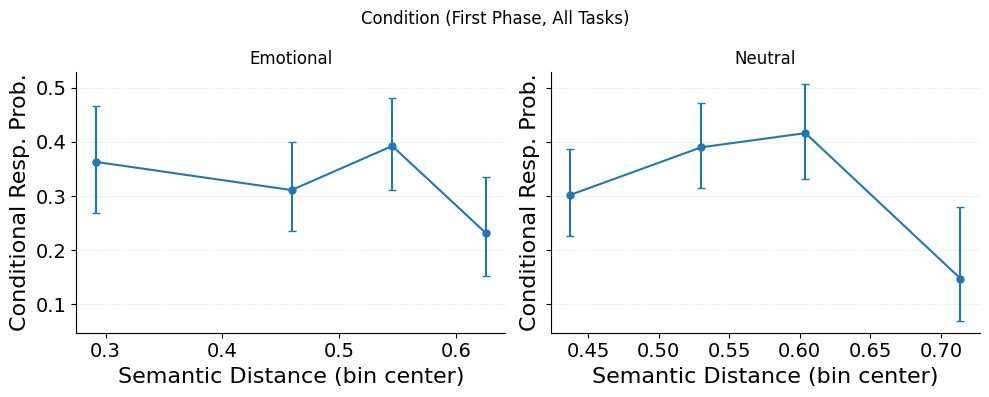

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_first_phase = first_phase_mask if use_first_phase_only else trial_mask(
    jnp.ones_like(task, dtype=bool)
)

mask_emotional = mask_first_phase & trial_mask(condition == 1)
labels = ["Emotional"]
masks = [mask_emotional]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Emotional")

mask_neutral = mask_first_phase & trial_mask(condition == 2)
labels = ["Neutral"]
masks = [mask_neutral]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[1])
axes[1].set_title("Neutral")

fig.suptitle(f"Condition ({phase_label}, All Tasks)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="semantic_condition_all_tasks")

## Q3. Task × Intervention (Podcast Vs Tetris)

Podcast: trials=120, subjects=120
Tetris: trials=120, subjects=120


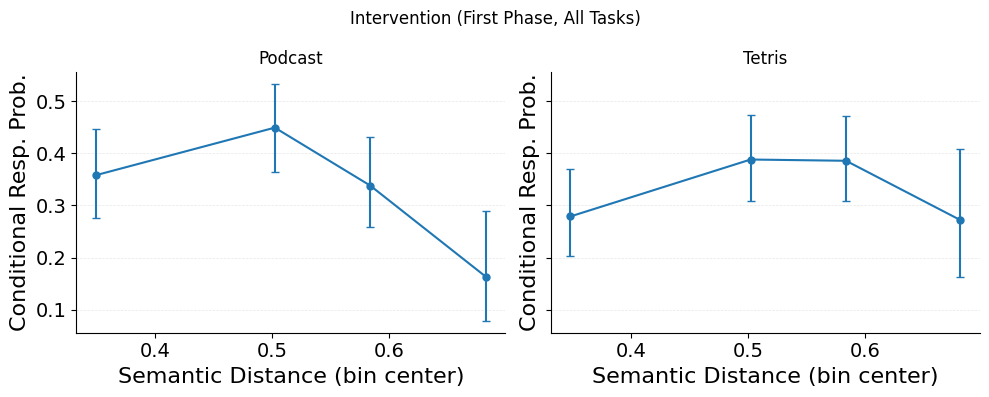

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_first_phase = first_phase_mask if use_first_phase_only else trial_mask(
    jnp.ones_like(task, dtype=bool)
)

mask_podcast = mask_first_phase & trial_mask(intervention == 0)
labels = ["Podcast"]
masks = [mask_podcast]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Podcast")

mask_tetris = mask_first_phase & trial_mask(intervention == 1)
labels = ["Tetris"]
masks = [mask_tetris]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[1])
axes[1].set_title("Tetris")

fig.suptitle(f"Intervention ({phase_label}, All Tasks)")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="semantic_intervention_all_tasks")

## Q4. Involuntary × Condition

Emotional: trials=60, subjects=60
Neutral: trials=60, subjects=60


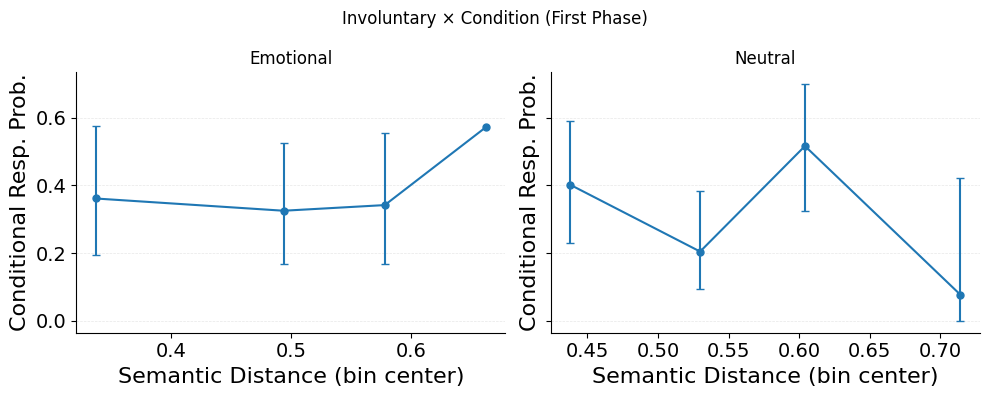

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_involuntary = phase_mask(task == 1)

mask_emotional = mask_involuntary & trial_mask(condition == 1)
labels = ["Emotional"]
masks = [mask_emotional]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Emotional")

mask_neutral = mask_involuntary & trial_mask(condition == 2)
labels = ["Neutral"]
masks = [mask_neutral]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[1])
axes[1].set_title("Neutral")

fig.suptitle(f"Involuntary × Condition ({phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="semantic_involuntary_condition")

## Q5. Voluntary × Condition

Emotional: trials=60, subjects=60
Neutral: trials=60, subjects=60


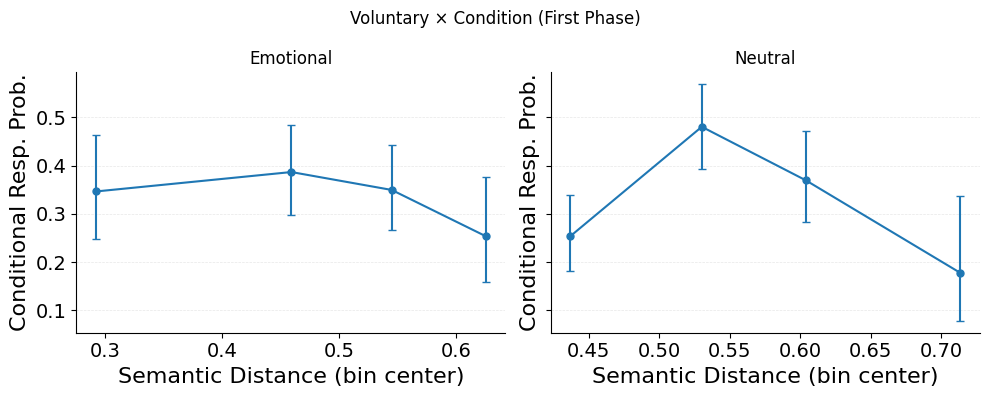

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_voluntary = phase_mask(task == 2)

mask_emotional = mask_voluntary & trial_mask(condition == 1)
labels = ["Emotional"]
masks = [mask_emotional]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Emotional")

mask_neutral = mask_voluntary & trial_mask(condition == 2)
labels = ["Neutral"]
masks = [mask_neutral]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[1])
axes[1].set_title("Neutral")

fig.suptitle(f"Voluntary × Condition ({phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="semantic_voluntary_condition")

## Q6. Involuntary × Intervention

Podcast: trials=60, subjects=60
Tetris: trials=60, subjects=60


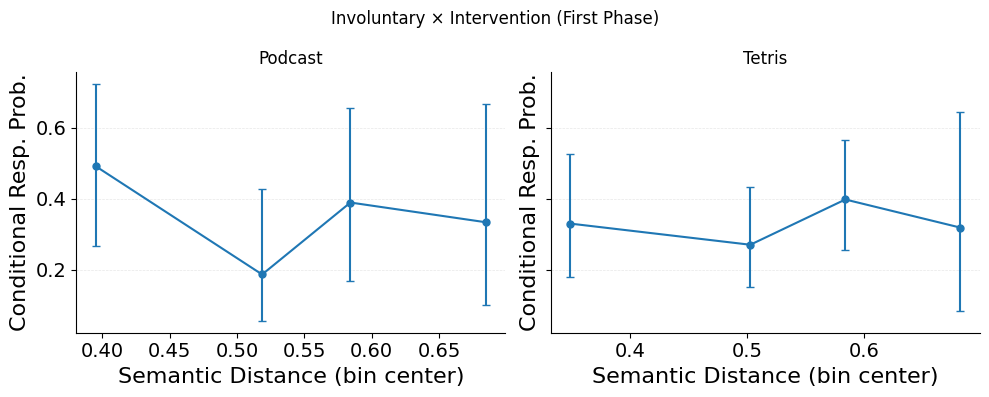

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_involuntary = phase_mask(task == 1)

mask_podcast = mask_involuntary & trial_mask(intervention == 0)
labels = ["Podcast"]
masks = [mask_podcast]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Podcast")

mask_tetris = mask_involuntary & trial_mask(intervention == 1)
labels = ["Tetris"]
masks = [mask_tetris]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[1])
axes[1].set_title("Tetris")

fig.suptitle(f"Involuntary × Intervention ({phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="semantic_involuntary_intervention")

## Q7. Voluntary × Intervention

Podcast: trials=60, subjects=60
Tetris: trials=60, subjects=60


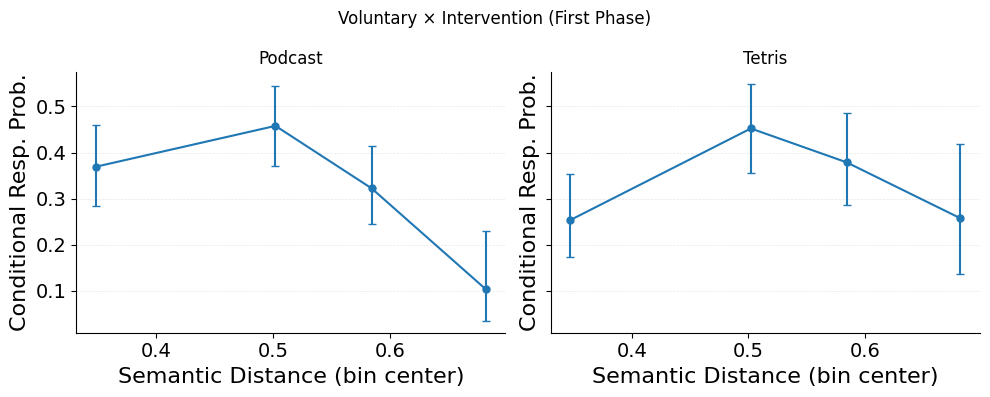

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

mask_voluntary = phase_mask(task == 2)

mask_podcast = mask_voluntary & trial_mask(intervention == 0)
labels = ["Podcast"]
masks = [mask_podcast]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[0])
axes[0].set_title("Podcast")

mask_tetris = mask_voluntary & trial_mask(intervention == 1)
labels = ["Tetris"]
masks = [mask_tetris]
summarize_masks(labels, masks)
plot_contrast([masks[0]], [labels[0]], contrast_name=None, axis=axes[1])
axes[1].set_title("Tetris")

fig.suptitle(f"Voluntary × Intervention ({phase_label})")
plt.tight_layout()
save_figure(figure_dir, figure_str, suffix="semantic_voluntary_intervention")